In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_combined_graphs, pinta_distribucion_categoricas, plot_categorical_relationship_fin,\
      plot_grouped_boxplots,plot_grouped_histograms, grafico_dispersion_con_correlacion, plot_categorical_numerical_relationship, bubble_plot
from scipy.stats import pearsonr, chi2_contingency, mannwhitneyu,f_oneway

Cargo los datos inmobiliarios

In [2]:
df_inm = pd.read_csv("EDA_Inmobiliario_Madridv2.csv", sep=",")

In [3]:
df_inm.head(5)

,titulo,precio,habitaciones,m2,altura,zona
0,"Piso en Calle de Jerónima Llorente, 74, Bellas...",1.900€/mes,3.0,75,Planta 1ª exterior con ascensor,"Bellas Vistas, Madrid"
1,"Dúplex en Calle del Doctor Santero, Bellas Vis...",5.300€/mes,4.0,192,NaN,"Bellas Vistas, Madrid"
2,"Piso en Calle de las Margaritas, 15, Berruguet...",800€/mes,1.0,27,Bajo exterior sin ascensor,"Berruguete, Madrid"
3,"Ático en Calle de Almansa, 7, Bellas Vistas, M...",1.578€/mes,1.0,42,Planta 3ª exterior sin ascensor,"Bellas Vistas, Madrid"
4,"Dúplex en Calle Aranjuez, 5, Bellas Vistas, Ma...",1.150€/mes,1.0,55,Bajo exterior con ascensor,"Bellas Vistas, Madrid"


In [4]:
# Correccion de los datos

df_inm['piso'] = df_inm['altura'].str.extract(r'(\d+)')   #quiero extraer uno o más dígitos dentro de a columna altura
df_inm['piso'] = df_inm['piso'].fillna(0)  # ejemplo: bajos = 0
df_inm['precio'] = pd.to_numeric(df_inm['precio'].str.replace('€/mes', '', regex=False).str.replace('.', '', regex=False).str.strip()) 
df_inm.head(5)

,titulo,precio,habitaciones,m2,altura,zona,piso
0,"Piso en Calle de Jerónima Llorente, 74, Bellas...",1900,3.0,75,Planta 1ª exterior con ascensor,"Bellas Vistas, Madrid",1
1,"Dúplex en Calle del Doctor Santero, Bellas Vis...",5300,4.0,192,NaN,"Bellas Vistas, Madrid",0
2,"Piso en Calle de las Margaritas, 15, Berruguet...",800,1.0,27,Bajo exterior sin ascensor,"Berruguete, Madrid",0
3,"Ático en Calle de Almansa, 7, Bellas Vistas, M...",1578,1.0,42,Planta 3ª exterior sin ascensor,"Bellas Vistas, Madrid",3
4,"Dúplex en Calle Aranjuez, 5, Bellas Vistas, Ma...",1150,1.0,55,Bajo exterior con ascensor,"Bellas Vistas, Madrid",0


In [5]:
# Em Chile el nivel bajo se considera un primer piso, o primera planta
df_inm['piso'] = pd.to_numeric(df_inm['piso']) 

df_inm['piso'] = df_inm['piso'] + 1

In [6]:
df_inm['precioeu_m2'] = df_inm['precio']/df_inm['m2']


In [7]:
df_inm = df_inm[['titulo','piso','m2','precio', 'habitaciones','precioeu_m2']]

df_inm.head(3)

,titulo,piso,m2,precio,habitaciones,precioeu_m2
0,"Piso en Calle de Jerónima Llorente, 74, Bellas...",2,75,1900,3.0,25.333333
1,"Dúplex en Calle del Doctor Santero, Bellas Vis...",1,192,5300,4.0,27.604167
2,"Piso en Calle de las Margaritas, 15, Berruguet...",1,27,800,1.0,29.629630


In [8]:
df_inm.info()

<class 'pandas.DataFrame'>
RangeIndex: 695 entries, 0 to 694
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   titulo        695 non-null    str    
 1   piso          695 non-null    int64  
 2   m2            695 non-null    int64  
 3   precio        695 non-null    int64  
 4   habitaciones  603 non-null    float64
 5   precioeu_m2   695 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 32.7 KB


In [9]:
df_inm.describe()

,piso,m2,precio,habitaciones,precioeu_m2
count,695.000000,695.000000,695.000000,603.000000,695.000000
mean,3.470504,70.545324,1770.615827,1.920398,28.481624
std,2.453940,36.314673,790.171007,0.920583,18.000696
min,1.000000,10.000000,590.000000,1.000000,10.882353
25%,2.000000,45.000000,1250.000000,1.000000,20.741758
50%,3.000000,64.000000,1600.000000,2.000000,24.875000
75%,4.000000,87.000000,2091.500000,2.000000,30.738636
max,22.000000,290.000000,6400.000000,5.000000,260.000000


(2,)


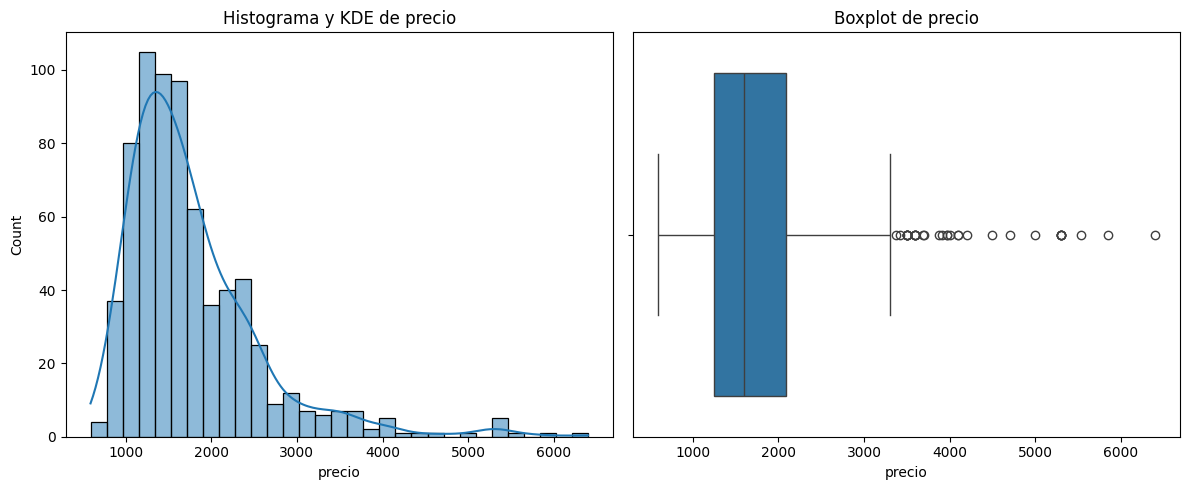

In [10]:
# El 50% es la mediana, el 50% de los datos están por debajo de ese numero

plot_combined_graphs(df_inm,["precio"])

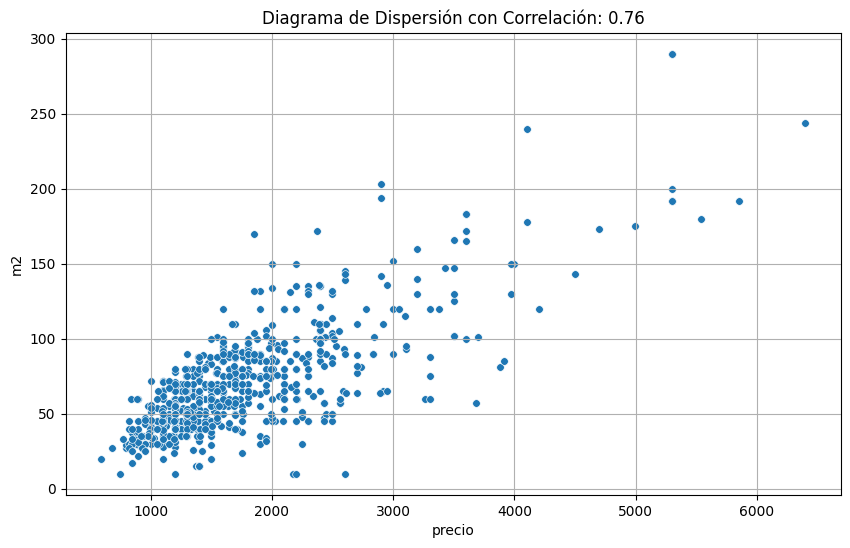

In [11]:
# Análisis bivariante
grafico_dispersion_con_correlacion(df_inm, "precio","m2", mostrar_correlacion= True, tamano_puntos= 30)

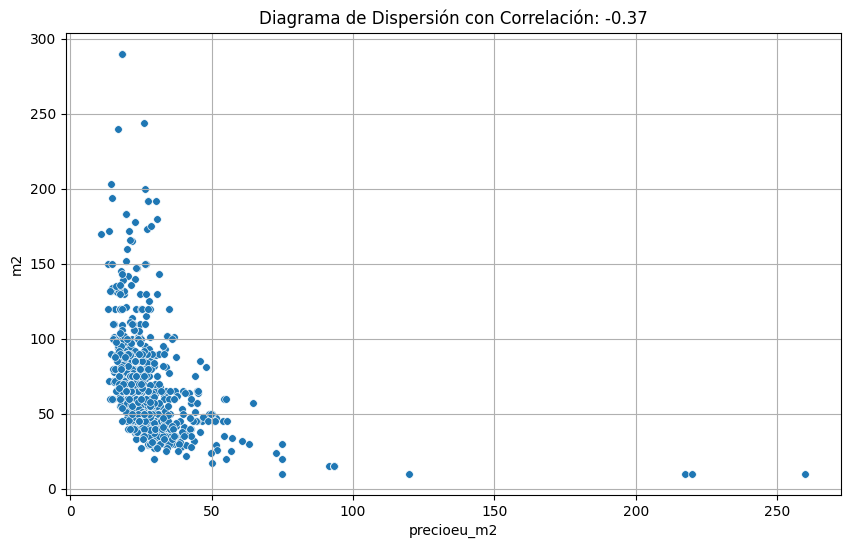

In [12]:
# Análisis bivariante

grafico_dispersion_con_correlacion(df_inm, "precioeu_m2","m2", mostrar_correlacion= True, tamano_puntos= 30)

In [13]:
# Análisis por grupo

rangos = [0, 40, 60, 80,100,120, float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100','100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precioeu_m2'].describe()

,count,mean,std,min,25%,50%,75%,max
grupo_m2,,,,,,,,
<40,117.0,45.056875,36.148171,20.625000,29.032258,34.142857,42.750000,260.000000
40-60,217.0,28.782332,8.780804,14.000000,23.333333,26.000000,32.978723,64.684211
60-80,158.0,23.889628,6.369080,13.888889,19.506410,22.761905,26.250000,45.384615
80-100,109.0,22.616740,5.999275,14.444444,18.703297,21.111111,25.100000,47.901235
100-120,39.0,22.873172,5.692697,13.333333,18.340979,22.641509,25.208333,36.633663
>120,55.0,20.826710,5.202051,10.882353,17.480504,19.672131,25.422446,31.468531


In [14]:
filtro = (df_inm.habitaciones == 2)&(df_inm.m2 >= 60)&(df_inm.m2 <= 80) 
df_inmf = df_inm[filtro]
df_inmf.head(30)

,titulo,piso,m2,precio,habitaciones,precioeu_m2,grupo_m2
15,"Piso en Ps Direccion, Valdeacederas, Madrid",2,78,1200,2.0,15.384615,60-80
26,"Piso en Calle de Sor Ángela de la Cruz, Cuzco-...",2,77,1700,2.0,22.077922,60-80
42,"Piso en Calle de José Calvo, 1, Berruguete, Ma...",6,64,1845,2.0,28.828125,60-80
49,"Piso en Calle de huesca, 7, Cuzco-Castillejos,...",3,70,1650,2.0,23.571429,60-80
50,"Piso en Calle de Jerónima Llorente, Bellas Vis...",2,65,1350,2.0,20.769231,60-80
52,"Piso en Calle de Francos Rodríguez, 34, Berrug...",3,75,1900,2.0,25.333333,60-80
61,"Piso en Calle de Almansa, Ciudad Universitaria...",13,75,2300,2.0,30.666667,60-80
65,"Piso en Calle de las Almortas, 40, Valdeaceder...",2,75,1700,2.0,22.666667,60-80
66,"Dúplex en Calle de Ceuta, 31, Valdeacederas, M...",4,80,1300,2.0,16.250000,60-80
77,"Piso en Calle de Olite, Bellas Vistas, Madrid",5,68,1700,2.0,25.000000,60-80


In [15]:
filtro = (df_inm.habitaciones == 2)&(df_inm.m2 >= 60)&(df_inm.m2 <= 80) 
df_inmf = df_inm[filtro]
df_inmf.describe()

,piso,m2,precio,habitaciones,precioeu_m2
count,97.000000,97.000000,97.000000,97.0,97.000000
mean,4.185567,70.288660,1752.453608,2.0,25.199253
std,2.994195,6.740671,459.224188,0.0,7.551951
min,1.000000,60.000000,1060.000000,2.0,15.000000
25%,2.000000,65.000000,1440.000000,2.0,21.285714
50%,3.000000,70.000000,1699.000000,2.0,23.333333
75%,5.000000,76.000000,1990.000000,2.0,27.500000
max,14.000000,80.000000,3300.000000,2.0,55.000000


In [17]:
# FILTRO PARA BÚSQUEDA FAMILIA
filtro = (df_inm.habitaciones >= 1)&(df_inm.m2 >= 60)&(df_inm.m2 <= 80) 
df_inmfil = df_inm[filtro]


rangos = [0, 40, 60, 80,100,120, float('inf')]
etiquetas = ['<40', '40-60', '60-80', '80-100','100-120','>120']

df_inm['grupo_m2'] = pd.cut(df_inm['m2'], bins=rangos, labels=etiquetas)

df_inm.groupby('grupo_m2')['precio'].describe()[["50%"]]

,50%
grupo_m2,
<40,1150.0
40-60,1350.0
60-80,1600.0
80-100,1875.0
100-120,2405.0
>120,3200.0


In [ ]:
# Para el grupo de 40–60 m², media ≈ 11.59 euro/m2 y la desviación es std ≈ 3.67

'''Esto significa que: Los precios suelen variar alrededor del promedio en ±3.67 (aprox.)
Es decir, muchos valores estarán entre: ~8 y ~15 (aproximadamente)

✅ En tu caso (precios por m²)
Desviación estándar alta
👉 Los precios dentro de ese grupo son muy variados
👉 Hay pisos baratos y caros aunque tengan tamaño similar
Desviación estándar baja
👉 Los precios son más consistentes
👉 El tamaño explica mejor el precio
'''

# Departamentos de menos de 60m2
filtro2 = (df_inm.m2 < 40)
df_inm40 = df_inm[filtro2]

df_inm40.head(2)

,titulo,piso,m2,precio,habitaciones,precioeu_m2,grupo_m2


In [ ]:
filtro = (df_inm.dormitorios > 1) #filtro por 2 dormitorios
df_inm2 = df_inm[filtro]
df_inm2.head(10)


NameError: name 'df_inm2' is not defined